In [ ]:
!pip install -q ultralytics
!pip install -q gradio pillow requests
print(" YOLOv8 installed!")

import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.4/107.7 GB disk)


In [1]:
# Install Grounding DINO and dependencies
!pip install -q torch torchvision
!pip install -q transformers
!pip install -q gradio pillow requests
!pip install -q supervision

print("Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
Packages installed


In [2]:
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from io import BytesIO

# Load Grounding DINO model
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

model_id  = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(model_id)
model     = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model      : Grounding DINO Base")
print(f"Parameters : {total_params:,}")
print("Model loaded successfully")

Device : cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

Model      : Grounding DINO Base
Parameters : 232,313,216
Model loaded successfully


Test 1: Street Scene


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Detected 7 objects:
  bus : 0.816
  person : 0.650
  person : 0.660
  person : 0.624
  traffic sign : 0.474
  person : 0.530
  building : 0.459

Test 2: Galaxy and Space
Detected 4 objects:
  spiral galaxy : 0.473
  space : 0.385
  planet : 0.450
   : 0.228


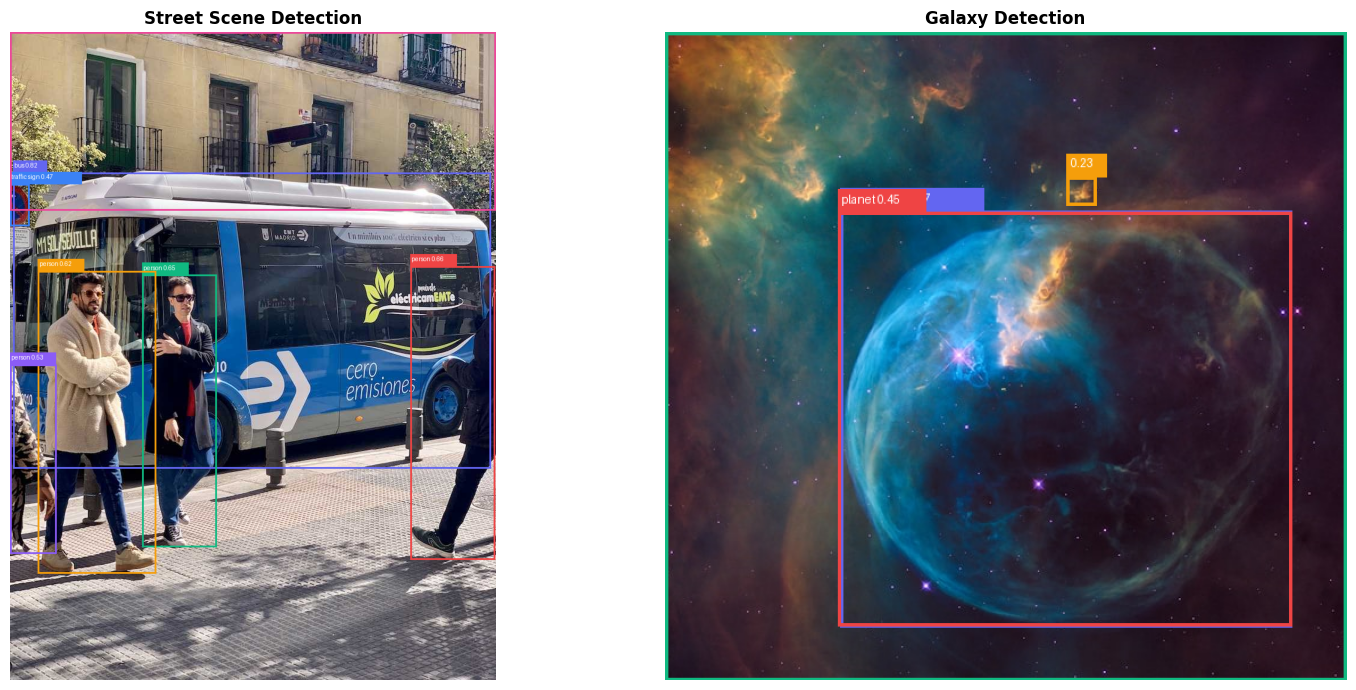

Test complete


In [7]:
def detect_objects(image, labels, threshold=0.3):
    # Grounding DINO expects labels as a dot-separated string
    text_prompt = " . ".join([l.strip() for l in labels]) + " ."

    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process detections
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]

    return results


def draw_detections(image, results):
    img_draw = image.copy()
    draw     = ImageDraw.Draw(img_draw)

    colors = ["#6366f1", "#10b981", "#ef4444", "#f59e0b",
              "#3b82f6", "#8b5cf6", "#ec4899", "#14b8a6"]

    boxes  = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()
    labels = results["labels"]

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        color   = colors[i % len(colors)]
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text = f"{label} {score:.2f}"
        draw.rectangle([x1, y1 - 20, x1 + len(text) * 7, y1], fill=color)
        draw.text((x1 + 2, y1 - 18), text, fill="white")

    return img_draw


# Test 1 — street scene
print("Test 1: Street Scene")
img1       = load_image_from_url("https://ultralytics.com/images/bus.jpg")
labels1    = ["bus", "person", "car", "traffic sign", "building"]
results1   = detect_objects(img1, labels1, threshold=0.3)
annotated1 = draw_detections(img1, results1)

print(f"Detected {len(results1['boxes'])} objects:")
for label, score in zip(results1["labels"], results1["scores"]):
    print(f"  {label} : {score:.3f}")

# Test 2 — galaxy and space
print("\nTest 2: Galaxy and Space")
img2       = load_image_from_url("https://images.unsplash.com/photo-1462331940025-496dfbfc7564?w=600")
labels2    = ["galaxy", "star", "nebula", "planet", "spiral galaxy", "space"]
results2   = detect_objects(img2, labels2, threshold=0.2)
annotated2 = draw_detections(img2, results2)

print(f"Detected {len(results2['boxes'])} objects:")
for label, score in zip(results2["labels"], results2["scores"]):
    print(f"  {label} : {score:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(annotated1)
axes[0].set_title("Street Scene Detection", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(annotated2)
axes[1].set_title("Galaxy Detection", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("grounding_dino_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Test complete")

Test 3: Kitchen Appliances
Detected 3 objects:
  kitchen : 0.468
  stove : 0.504
  sink : 0.254

Test 4: House and Building
Detected 27 objects:
  house : 0.598
  window : 0.605
  tree : 0.446
  window : 0.598
  window : 0.610
  tree : 0.503
  tree : 0.584
  window : 0.409
  roof : 0.371
  roof : 0.408
  house : 0.322
  window : 0.353
  garden : 0.379
  garden : 0.347
  tree : 0.402
  house : 0.364
  roof : 0.267
  fence : 0.331
  door : 0.329
  tree : 0.264
  fence : 0.438
  tree : 0.308
  tree : 0.259
  garage : 0.392
  window : 0.376
  window : 0.262
  tree : 0.275


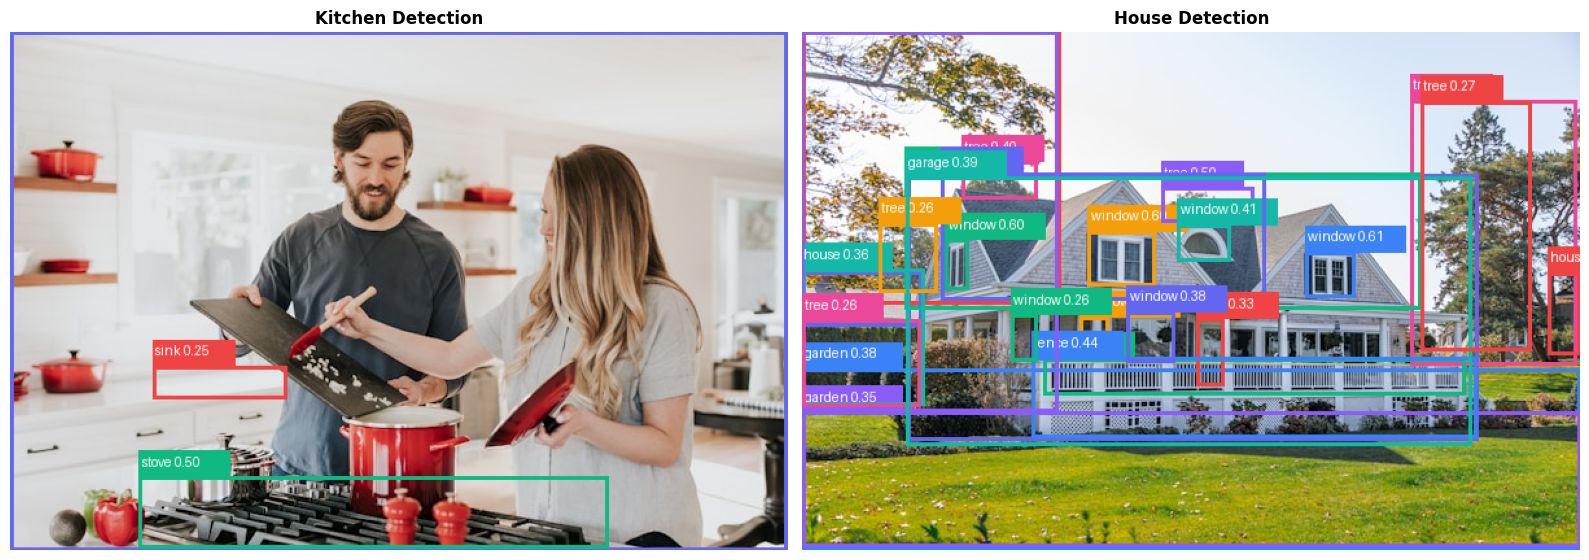

Test complete


In [8]:
def detect_objects(image, labels, threshold=0.3):
    # Grounding DINO expects labels as a dot-separated string
    text_prompt = " . ".join([l.strip() for l in labels]) + " ."

    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Use text_labels instead of labels to avoid deprecation warning
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]

    # Use text_labels for string names
    results["labels"] = results["text_labels"]
    return results


def draw_detections(image, results):
    img_draw = image.copy()
    draw     = ImageDraw.Draw(img_draw)

    colors = ["#6366f1", "#10b981", "#ef4444", "#f59e0b",
              "#3b82f6", "#8b5cf6", "#ec4899", "#14b8a6"]

    boxes  = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()
    labels = results["labels"]

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        if not label.strip():
            continue
        color   = colors[i % len(colors)]
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text = f"{label} {score:.2f}"
        draw.rectangle([x1, y1 - 20, x1 + len(text) * 7, y1], fill=color)
        draw.text((x1 + 2, y1 - 18), text, fill="white")

    return img_draw


# Test kitchen/home appliances
print("Test 3: Kitchen Appliances")
img3     = load_image_from_url("https://images.unsplash.com/photo-1556909114-f6e7ad7d3136?w=600")
labels3  = ["microwave", "oven", "refrigerator", "counter", "sink", "cabinet", "stove", "kitchen"]
results3 = detect_objects(img3, labels3, threshold=0.25)
annotated3 = draw_detections(img3, results3)

print(f"Detected {len(results3['boxes'])} objects:")
for label, score in zip(results3["labels"], results3["scores"]):
    print(f"  {label} : {score:.3f}")

# Test house/building
print("\nTest 4: House and Building")
img4     = load_image_from_url("https://images.unsplash.com/photo-1570129477492-45c003edd2be?w=600")
labels4  = ["house", "window", "door", "roof", "tree", "garden", "fence", "garage"]
results4 = detect_objects(img4, labels4, threshold=0.25)
annotated4 = draw_detections(img4, results4)

print(f"Detected {len(results4['boxes'])} objects:")
for label, score in zip(results4["labels"], results4["scores"]):
    print(f"  {label} : {score:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(annotated3)
axes[0].set_title("Kitchen Detection", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(annotated4)
axes[1].set_title("House Detection", fontweight="bold")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("grounding_dino_test2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Test complete")

In [9]:
app_code = '''
import gradio as gr
import torch
import requests
import numpy as np
from PIL import Image, ImageDraw
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from io import BytesIO

# Load Grounding DINO model
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id  = "IDEA-Research/grounding-dino-base"
processor = AutoProcessor.from_pretrained(model_id)
model     = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)
model.eval()

def load_image_from_url(url):
    response = requests.get(url, timeout=10)
    return Image.open(BytesIO(response.content)).convert("RGB")

def detect_objects(image, labels_text, threshold):
    if image is None:
        return None, "Please upload an image."

    # Parse labels and build text prompt
    labels      = [l.strip() for l in labels_text.split(",") if l.strip()]
    text_prompt = " . ".join(labels) + " ."

    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]

    results["labels"] = results["text_labels"]

    # Draw detections
    img_draw = image.copy()
    draw     = ImageDraw.Draw(img_draw)

    colors = ["#6366f1", "#10b981", "#ef4444", "#f59e0b",
              "#3b82f6", "#8b5cf6", "#ec4899", "#14b8a6",
              "#f97316", "#06b6d4", "#84cc16", "#a855f7"]

    boxes  = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()
    labels = results["labels"]

    # Count detections per label
    label_counts = {}
    for label in labels:
        if label.strip():
            label_counts[label] = label_counts.get(label, 0) + 1

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        if not label.strip():
            continue
        color   = colors[i % len(colors)]
        x1, y1, x2, y2 = box
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        text = f"{label} {score:.2f}"
        draw.rectangle([x1, y1 - 20, x1 + len(text) * 7, y1], fill=color)
        draw.text((x1 + 2, y1 - 18), text, fill="white")

    # Build summary
    total   = len([l for l in labels if l.strip()])
    summary = f"### Detected {total} object(s)\\n\\n"

    counts = {}
    for label in labels:
        if label.strip():
            counts[label] = counts.get(label, 0) + 1

    for label, count in sorted(counts.items(), key=lambda x: -x[1]):
        bar     = "█" * min(count * 4, 24)
        summary += f"**{label}** — {count}x {bar}\\n\\n"

    if total == 0:
        summary = "No objects detected. Try lowering the threshold or adding more specific labels."

    return img_draw, summary


# Preset label groups for quick access
presets = {
    "Street Scene"      : "person, car, bus, truck, bicycle, traffic light, traffic sign, building, road",
    "Kitchen"           : "microwave, oven, refrigerator, sink, stove, cabinet, counter, toaster, kettle",
    "Living Room"       : "sofa, chair, table, television, lamp, bookshelf, carpet, cushion, window",
    "Space & Galaxy"    : "galaxy, star, nebula, planet, spiral galaxy, moon, comet, asteroid",
    "Animals"           : "dog, cat, bird, horse, elephant, lion, tiger, bear, rabbit, fish",
    "Sports"            : "person, ball, goal, net, court, stadium, athlete, referee, jersey",
    "Office"            : "laptop, monitor, keyboard, mouse, desk, chair, phone, printer, notebook",
    "Nature"            : "tree, flower, grass, mountain, river, rock, cloud, sky, waterfall, forest",
}

css = """
@import url("https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800;900&display=swap");
:root {
    --bg-primary:#ffffff; --bg-card:#ffffff; --bg-elevated:#f1f5f9;
    --border:rgba(0,0,0,0.08); --text-primary:#0f172a; --text-secondary:#475569;
    --text-tertiary:#94a3b8; --accent:#f59e0b; --accent-dim:rgba(245,158,11,0.1);
    --shadow:0 4px 6px -1px rgba(0,0,0,0.07); --shadow-lg:0 10px 15px -3px rgba(0,0,0,0.08);
    --radius:16px;
}
[data-theme="dark"] {
    --bg-primary:#0f172a; --bg-card:#1e293b; --bg-elevated:#334155;
    --border:rgba(255,255,255,0.08); --text-primary:#f1f5f9;
    --text-secondary:#94a3b8; --text-tertiary:#475569;
    --shadow:0 4px 6px -1px rgba(0,0,0,0.3); --shadow-lg:0 10px 15px -3px rgba(0,0,0,0.4);
}
* { font-family:"Inter",sans-serif !important; box-sizing:border-box; }
body,.gradio-container { background:var(--bg-primary) !important; color:var(--text-primary) !important; transition:all 0.3s ease; }
.gradio-container { max-width:1100px !important; margin:0 auto !important; padding:24px !important; }
.app-header { text-align:center; padding:52px 24px 36px; background:linear-gradient(135deg,var(--accent-dim),transparent); border-radius:var(--radius); border:1px solid var(--border); margin-bottom:28px; }
.app-header h1 { font-size:2.4em !important; font-weight:900 !important; background:linear-gradient(135deg,var(--accent),#ef4444,#8b5cf6); -webkit-background-clip:text !important; -webkit-text-fill-color:transparent !important; margin-bottom:14px !important; }
.app-header p { color:var(--text-secondary) !important; font-size:1em !important; max-width:640px; margin:0 auto !important; line-height:1.8 !important; }
.badges { display:flex; justify-content:center; gap:10px; flex-wrap:wrap; margin-top:20px; }
.badge { padding:6px 16px; border-radius:20px; font-size:0.75em; font-weight:600; border:1px solid var(--border); background:var(--bg-elevated); color:var(--text-secondary); }
.badge.accent { background:var(--accent-dim); color:var(--accent); border-color:rgba(245,158,11,0.25); }
.badge.positive { background:rgba(16,185,129,0.1); color:#10b981; border-color:rgba(16,185,129,0.25); }
.stats-row { display:grid; grid-template-columns:repeat(4,1fr); gap:16px; margin-bottom:28px; }
.stat-card { background:var(--bg-card); border:1px solid var(--border); border-radius:var(--radius); padding:20px 16px; text-align:center; box-shadow:var(--shadow); transition:all 0.2s ease; }
.stat-card:hover { transform:translateY(-2px); box-shadow:var(--shadow-lg); }
.stat-value { font-size:1.9em; font-weight:900; color:var(--accent); line-height:1; }
.stat-label { font-size:0.7em; color:var(--text-tertiary); font-weight:600; text-transform:uppercase; letter-spacing:0.8px; margin-top:6px; }
.card { background:var(--bg-card) !important; border:1px solid var(--border) !important; border-radius:var(--radius) !important; padding:24px !important; box-shadow:var(--shadow) !important; }
.theme-toggle { position:fixed !important; top:20px !important; right:20px !important; background:var(--bg-card) !important; border:1px solid var(--border) !important; border-radius:50% !important; width:46px !important; height:46px !important; cursor:pointer !important; font-size:1.2em !important; box-shadow:var(--shadow-lg) !important; transition:all 0.2s !important; z-index:1000 !important; }
.theme-toggle:hover { transform:scale(1.12) rotate(15deg) !important; }
button.primary { background:linear-gradient(135deg,var(--accent),#ef4444) !important; border:none !important; border-radius:12px !important; color:white !important; font-weight:700 !important; font-size:1em !important; padding:14px 28px !important; width:100% !important; cursor:pointer !important; transition:all 0.25s !important; box-shadow:0 4px 15px rgba(245,158,11,0.4) !important; }
button.primary:hover { transform:translateY(-2px) !important; box-shadow:0 8px 25px rgba(245,158,11,0.5) !important; }
label { color:var(--text-secondary) !important; font-weight:700 !important; font-size:0.78em !important; text-transform:uppercase !important; letter-spacing:1px !important; }
.footer { text-align:center; padding:28px; color:var(--text-tertiary); font-size:0.78em; border-top:1px solid var(--border); margin-top:36px; line-height:2; }
"""

js = """
function toggleTheme(){
    const root=document.documentElement;
    const btn=document.getElementById("theme-btn");
    const dark=root.getAttribute("data-theme")==="dark";
    root.setAttribute("data-theme",dark?"light":"dark");
    btn.textContent=dark?"🌙":"☀️";
    localStorage.setItem("gdino-theme",dark?"light":"dark");
}
document.addEventListener("DOMContentLoaded",()=>{
    const saved=localStorage.getItem("gdino-theme")||"light";
    document.documentElement.setAttribute("data-theme",saved);
    const btn=document.getElementById("theme-btn");
    if(btn)btn.textContent=saved==="dark"?"☀️":"🌙";
});
"""

with gr.Blocks(css=css, title="Grounding DINO Object Detector") as demo:

    gr.HTML(f"""
    <button class="theme-toggle" id="theme-btn" onclick="toggleTheme()">🌙</button>
    <script>{js}</script>
    <div class="app-header">
        <h1>Grounding DINO Object Detector</h1>
        <p>Open-vocabulary object detection — detect anything you can describe in text.
        No fixed class limit. Works on galaxies, appliances, rooms, nature and more.</p>
        <div class="badges">
            <span class="badge accent">Grounding DINO</span>
            <span class="badge accent">232M Parameters</span>
            <span class="badge positive">Open Vocabulary</span>
            <span class="badge positive">Zero-shot</span>
            <span class="badge">Any Object</span>
            <span class="badge">8 Presets</span>
        </div>
    </div>
    <div class="stats-row">
        <div class="stat-card">
            <div class="stat-value">232M</div>
            <div class="stat-label">Parameters</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">Unlimited</div>
            <div class="stat-label">Object Classes</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">Zero-shot</div>
            <div class="stat-label">No Fine-tuning</div>
        </div>
        <div class="stat-card">
            <div class="stat-value">8</div>
            <div class="stat-label">Quick Presets</div>
        </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1, elem_classes=["card"]):
            gr.Markdown("### Upload Image")
            input_image = gr.Image(type="pil", label="Image", height=280)

            labels_input = gr.Textbox(
                label="Objects to Detect (comma separated)",
                placeholder="person, car, building, tree...",
                value="person, car, bus, building, tree",
                lines=2
            )

            threshold = gr.Slider(
                minimum=0.1, maximum=0.7,
                value=0.3, step=0.05,
                label="Detection Threshold"
            )

            detect_btn = gr.Button("Detect Objects", variant="primary")

            gr.Markdown("#### Quick Presets")
            with gr.Row():
                for name in list(presets.keys())[:4]:
                    btn = gr.Button(name, size="sm")
                    btn.click(fn=lambda x=presets[name]: x, outputs=labels_input)
            with gr.Row():
                for name in list(presets.keys())[4:]:
                    btn = gr.Button(name, size="sm")
                    btn.click(fn=lambda x=presets[name]: x, outputs=labels_input)

        with gr.Column(scale=1, elem_classes=["card"]):
            gr.Markdown("### Detection Results")
            output_image = gr.Image(label="Annotated Image", height=280)
            output_text  = gr.Markdown(value="Upload an image and click Detect Objects.")

    gr.HTML("""
    <div style="margin-top:28px;background:var(--bg-card);border:1px solid var(--border);border-radius:16px;padding:28px;box-shadow:var(--shadow);">
        <h3 style="color:var(--text-primary);margin-bottom:20px;font-size:1em;font-weight:700;">Why Grounding DINO vs YOLOv8</h3>
        <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(220px,1fr));gap:16px;">
            <div style="padding:16px;background:var(--bg-elevated);border-radius:12px;">
                <div style="font-weight:700;color:var(--text-primary);font-size:0.9em;margin-bottom:8px;">YOLOv8</div>
                <div style="color:var(--text-tertiary);font-size:0.78em;line-height:1.8;">
                    Fixed 80 COCO classes only<br>
                    Cannot detect custom objects<br>
                    Fast inference<br>
                    Struggles with rare objects
                </div>
            </div>
            <div style="padding:16px;background:var(--bg-elevated);border-radius:12px;border:1px solid rgba(245,158,11,0.3);">
                <div style="font-weight:700;color:var(--accent);font-size:0.9em;margin-bottom:8px;">Grounding DINO</div>
                <div style="color:var(--text-tertiary);font-size:0.78em;line-height:1.8;">
                    Unlimited custom classes<br>
                    Detect anything you describe<br>
                    Open-vocabulary detection<br>
                    State of the art accuracy
                </div>
            </div>
        </div>
    </div>
    <div class="footer">
        Grounding DINO Base • 232M Parameters • Open-vocabulary Detection •
        <a href="https://github.com/Boatengs/yolo-object-detector" target="_blank" style="color:var(--accent);">GitHub</a>
    </div>
    """)

    detect_btn.click(
        fn=detect_objects,
        inputs=[input_image, labels_input, threshold],
        outputs=[output_image, output_text]
    )

demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)

with open("requirements.txt", "w") as f:
    f.write("gradio\ntransformers\ntorch\ntorchvision\nPillow\nrequests\nnumpy\n")

print("app.py and requirements.txt created")

app.py and requirements.txt created


In [10]:
from huggingface_hub import HfApi

HF_TOKEN = "YOUR_HF_TOKEN_HERE"
api = HfApi(token=HF_TOKEN)

user = api.whoami()
print(f"Logged in as: {user['name']}")

api.upload_file(
    path_or_fileobj="app.py",
    path_in_repo="app.py",
    repo_id="samurvivor-07/yolov8-object-detector",
    repo_type="space",
    token=HF_TOKEN
)
print("app.py pushed")

api.upload_file(
    path_or_fileobj="requirements.txt",
    path_in_repo="requirements.txt",
    repo_id="samurvivor-07/yolov8-object-detector",
    repo_type="space",
    token=HF_TOKEN
)
print("requirements.txt pushed")

print("Live at: https://huggingface.co/spaces/samurvivor-07/yolov8-object-detector")

Logged in as: samurvivor-07
app.py pushed
requirements.txt pushed
Live at: https://huggingface.co/spaces/samurvivor-07/yolov8-object-detector


In [11]:
from google.colab import files

files.download('app.py')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>